<a href="https://colab.research.google.com/github/Code-eram/skills-introduction-to-github/blob/main/Netflix_Business_case_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aim: Analysing which type of Movie/shows to produce and Recommendations that helps Netflix grow its Business.

In [ ]:
# importing required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# loading the provided dataset
df=pd.read_csv('netflix.csv')

In [ ]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
# It is important to check the data types of all columns.
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


#Basic Analysis

In [ ]:
# Basic shape and info
print(df.shape)
print(df.info())
print(df.describe(include='all'))


(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None
       show_id   type   title       director                cast  \
count     8807   8807    8807           6173                7982   
unique    8807      2    8807           4528                7692   
top      s8807  Movie  Zubaan  R

We see the date_added column is object type , thus we are converting the column type to datetime.

In [ ]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])


 1. unnesting Columns which has comma seperated values into multiple rows . This helps in better analysis , with specific requirements.


In [ ]:
df['country'] = df['country'].str.split(',')
df = df.explode('country')
df['country'] = df['country'].str.strip()

df['listed_in']=df['listed_in'].str.split(',')
df=df.explode('listed_in')
df['listed_in']=df['listed_in'].str.strip()

df['cast']=df['cast'].str.split(',')
df=df.explode('cast')
df['cast']=df['cast'].str.strip()


The dataset has null values present , and it is important to handle missing values.

In [ ]:
# we check the count of null values present.
print(df.isnull().sum())


show_id             0
type                0
title               0
director        50643
cast             1848
country         11145
date_added        158
release_year        0
rating             67
duration            3
listed_in           0
description         0
dtype: int64


In [ ]:
# for categorical null values
df['director']=df['director'].fillna('Unknown director')
df['cast']=df['cast'].fillna('Unknown cast')
df['country']=df['country'].fillna('Unknown country')
df['rating']=df['rating'].fillna('unknown rating')
df['duration']=df['duration'].fillna('Unknown duration')

# for numerical/continuous vals filling with 0

df['release_year']=df['release_year'].fillna(0)

In [ ]:
# converting  columns to category.
for col in ['type', 'rating', 'country', 'director','listed_in']:
    df[col] = df[col].astype('category')


Post Basic Analysis , We are now figuring the trends in data .

Counting the total values present in each column.

In [ ]:
# Selecting categorical columns, non graphical
cat_cols = df.select_dtypes(include='category').columns
# # Value counts for each
for col in cat_cols:
    print(f"\nValue counts for '{col}':")
    print(df[col].value_counts())


Value counts for 'type':
type
Movie      131931
TV Show     54468
Name: count, dtype: int64

Value counts for 'director':
director
Unknown director                                      50643
Martin Scorsese                                         419
Youssef Chahine                                         409
Cathy Garcia-Molina                                     356
Steven Spielberg                                        355
                                                      ...  
Rik Reinholdtsen                                          1
Paul M. Green                                             1
Adam Davis, Jerry Kolber, Trey Nelson, Erich Sturm        1
Adam Bolt                                                 1
Yoo Byung-jae                                             1
Name: count, Length: 4529, dtype: int64

Value counts for 'country':
country
United States      54220
India              21147
United Kingdom     12424
Unknown country    11145
Japan               7940
      

/tmp/ipython-input-573552548.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='type',palette="dark")


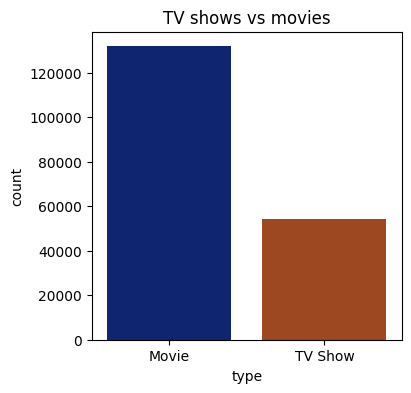

In [ ]:
# 1.b. graphically counting the total values
# column--> type
plt.figure(figsize=(4, 4))
sns.countplot(data=df,x='type',palette="dark")
plt.title('TV shows vs movies')
plt.show()

/tmp/ipython-input-79187553.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=filtered_df, x='rating', order=top_10,palette='viridis')


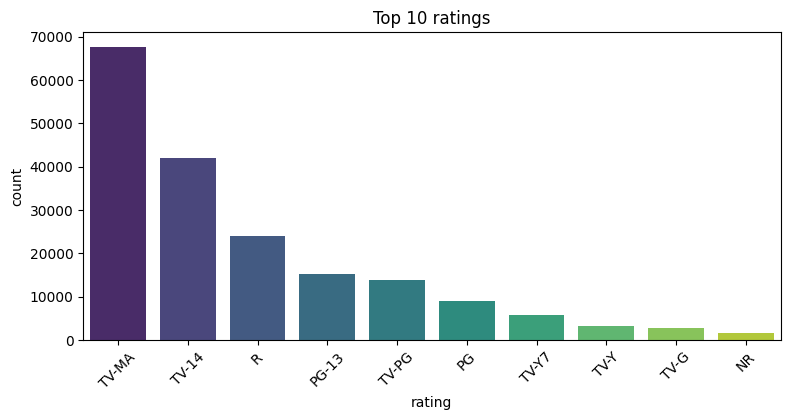

In [ ]:
# count of top 10 ratings
df = df[df['rating'] != 'unknown rating']
top_10 = df['rating'].value_counts().head(10).index.tolist()
filtered_df = df[df['rating'].isin(top_10)]

plt.figure(figsize=(9, 4))
sns.countplot(data=filtered_df, x='rating', order=top_10,palette='viridis')
plt.title('Top 10 ratings')
plt.xticks(rotation=45)  # or 90 or any angle you want
plt.show()


/tmp/ipython-input-2751553589.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=filtered_df, x='director', order=top_10,palette=['#432371', '#FAAE7B', '#0000FF'])
/tmp/ipython-input-2751553589.py:7: UserWarning: 
The palette list has fewer values (3) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=filtered_df, x='director', order=top_10,palette=['#432371', '#FAAE7B', '#0000FF'])


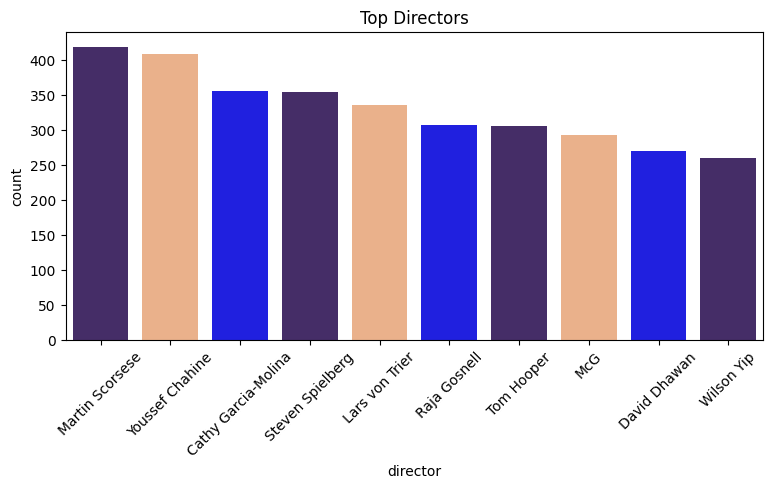

In [ ]:
# count of top 10 directors
df = df[df['director'] != 'Unknown director']
top_10 = df['director'].value_counts().head(10).index.tolist()
filtered_df = df[df['director'].isin(top_10)]

plt.figure(figsize=(9, 4))
sns.countplot(data=filtered_df, x='director', order=top_10,palette=['#432371', '#FAAE7B', '#0000FF'])
plt.title('Top Directors')
plt.xticks(rotation=45)  # or 90 or any angle you want
plt.show()


/tmp/ipython-input-1047043618.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=filtered_df, x='country', order=top_10,palette='dark')


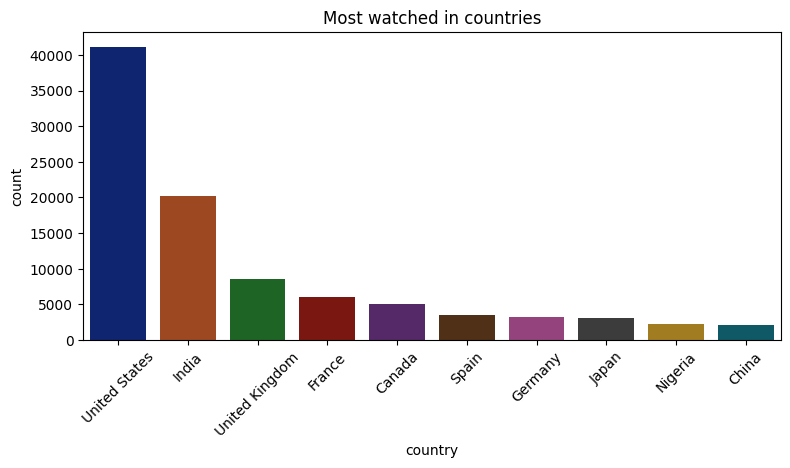

In [ ]:
# most watched in countries
df = df[df['country'] != 'Unknown country']
top_10 = df['country'].value_counts().head(10).index.tolist()
filtered_df = df[df['country'].isin(top_10)]

plt.figure(figsize=(9, 4))
sns.countplot(data=filtered_df, x='country', order=top_10,palette='dark')
plt.title('Most watched in countries')
plt.xticks(rotation=45)  # or 90 or any angle you want
plt.show()


/tmp/ipython-input-2288996108.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=filtered_df, x='listed_in', order=top_10,palette='bright')


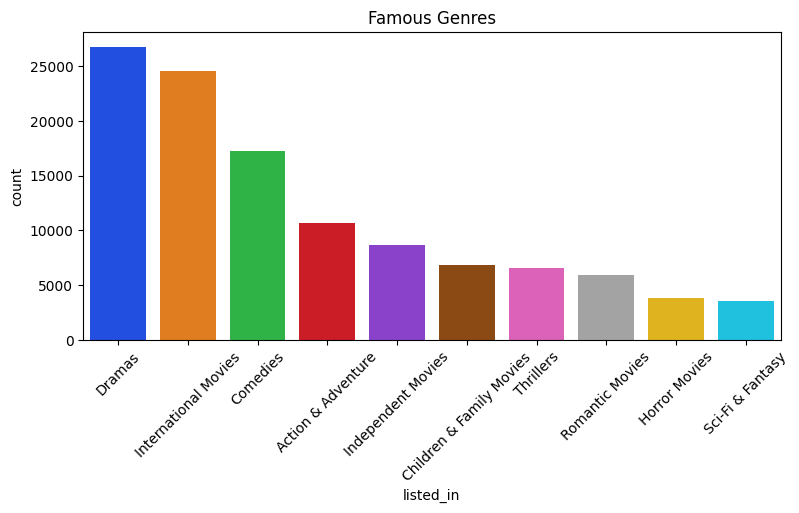

In [ ]:
# popular Genre
top_10 = df['listed_in'].value_counts().head(10).index.tolist()
filtered_df = df[df['listed_in'].isin(top_10)]

plt.figure(figsize=(9, 4))
sns.countplot(data=filtered_df, x='listed_in', order=top_10,palette='bright')
plt.title('Famous Genres')
plt.xticks(rotation=45)  # or 90 or any angle you want
plt.show()


Conclusion:
Movies are the most watched than TV Shows in Netflix among viewers, the top rating among all is TV-MA.Martin Scorsese has directed most number of movies/shows among the rest of directors, while Youssefe Chahine is also popular . Netflix is mostly used by people of United States, compared to rest of the countries and the famous Genre is Drama. We also see International movies is popular too.

Lets dive in more and see the comparison between TV Shows and Movies

1.Checking how many movies have been produced in each country

In [ ]:
movies_df = df[df['type'] == 'Movie']
country_counts = movies_df.groupby('country')['title'].nunique().sort_values(ascending=False).head(10)
# print(country_counts)
print(country_counts)

country
United States     2684
India              950
United Kingdom     513
Canada             309
France             302
Germany            177
Spain              166
Japan              118
China              112
Mexico             109
Name: title, dtype: int64


/tmp/ipython-input-2495136230.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_counts = movies_df.groupby('country')['title'].nunique().sort_values(ascending=False).head(10)


The total number of TV Shows produced in each country

In [ ]:
shows_df = df[df['type'] == 'TV Show']
country_counts = shows_df.groupby('country')['title'].nunique().sort_values(ascending=False).head(10)
# print(country_counts)
print(country_counts)

country
United States     66
United Kingdom    26
Spain             15
Japan             12
South Korea       12
India             11
France             9
Taiwan             8
Canada             8
Brazil             7
Name: title, dtype: int64


/tmp/ipython-input-1109829519.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_counts = shows_df.groupby('country')['title'].nunique().sort_values(ascending=False).head(10)


This can be visually seen , here we are doing multivariate analysis.

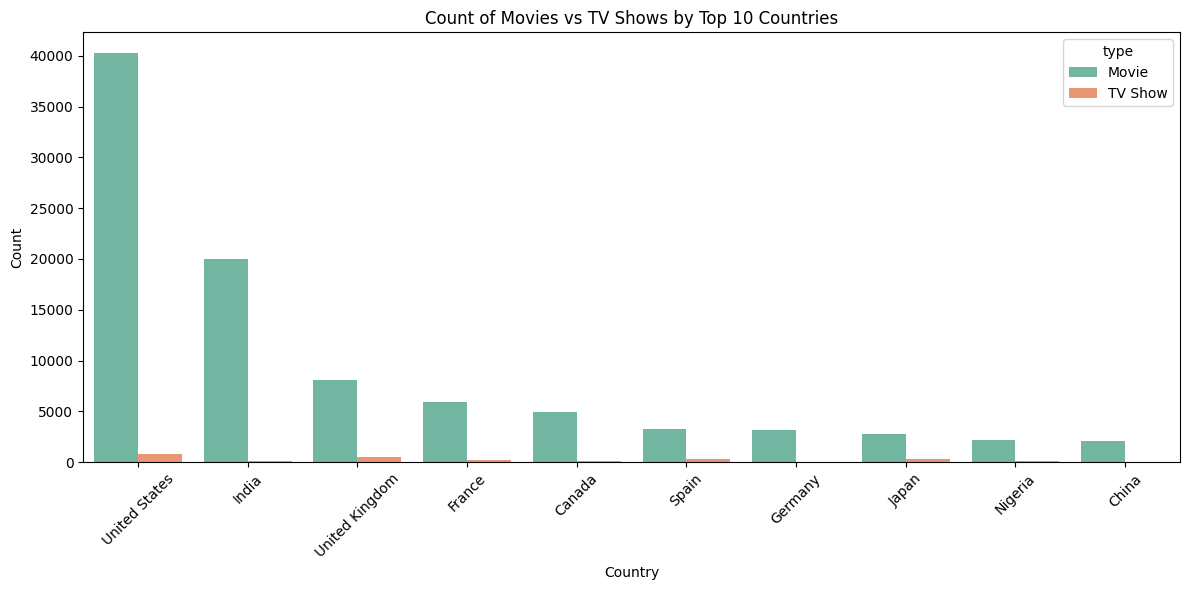

In [ ]:
# top 10 countries by total count
top_countries = df['country'].value_counts().nlargest(10).index

# Filtering to only top countries
df_top = df[df['country'].isin(top_countries)]

plt.figure(figsize=(12, 6))
sns.countplot(data=df_top, x='country', hue='type', order=top_countries, palette='Set2')

plt.title('Count of Movies vs TV Shows by Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Conclusion: TV Shows are watched negligibly as compared to Movies in popular countries. Producing more movies than TV Shows can help in attracting viewers.

It is crucial to know which is the best time to release TV Shows/Movies.
we start with checking  which week is best to release.

In [ ]:
# converting the date_added to calender week.
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['week'] = df['date_added'].dt.isocalendar().week

In [ ]:
# Convert 'date_added' to datetime
df['date_added'] = pd.to_datetime(df['date_added'])

# Extract the year Netflix added the title
df['year_added'] = df['date_added'].dt.year


In [ ]:
release_trend = df['release_year'].value_counts().sort_index()
release_trend


,count
release_year,
1942,6
1943,4
1944,8
1945,8
1946,3
...,...
2017,13519
2018,14981
2019,10836


In [ ]:
added_trend = df['year_added'].value_counts().sort_index()
added_trend


,count
year_added,
2008,18
2009,30
2010,20
2011,303
2012,36
2013,104
2014,253
2015,820
2016,3960


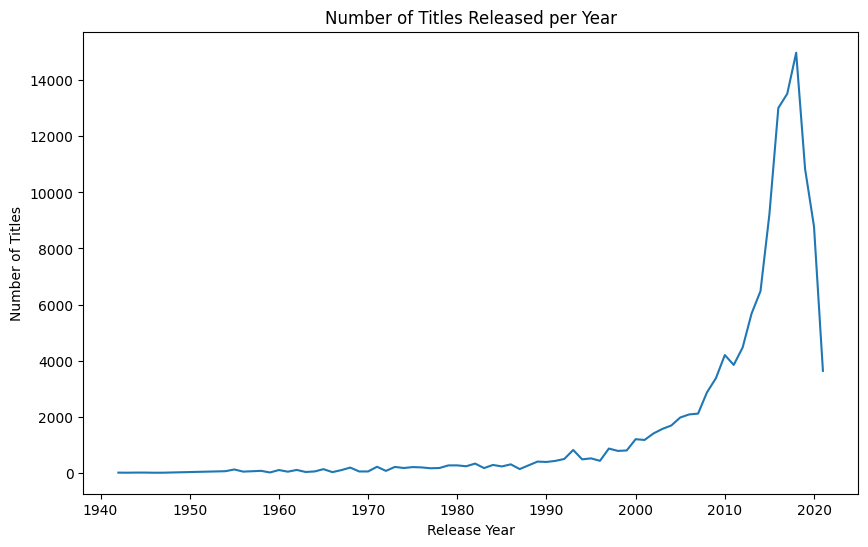

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.lineplot(x=release_trend.index, y=release_trend.values)
plt.title("Number of Titles Released per Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()


In [ ]:
# Mark titles that are likely Netflix Originals
df['is_original'] = df['title'].str.contains("Netflix", case=False, na=False) | \
                    df['description'].str.contains("Netflix", case=False, na=False)


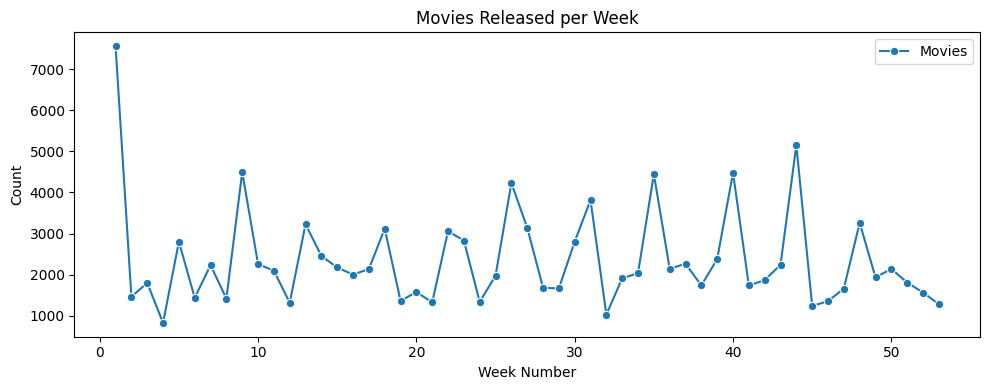

In [ ]:
# movie week counts
movies = df[df['type'] == 'Movie']
movies_by_week = movies.groupby('week')['show_id'].count().reset_index(name='movie_count')
plt.figure(figsize=(10, 4))
sns.lineplot(data=movies_by_week, x='week', y='movie_count', marker='o', label='Movies')
plt.title('Movies Released per Week')
plt.xlabel('Week Number')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

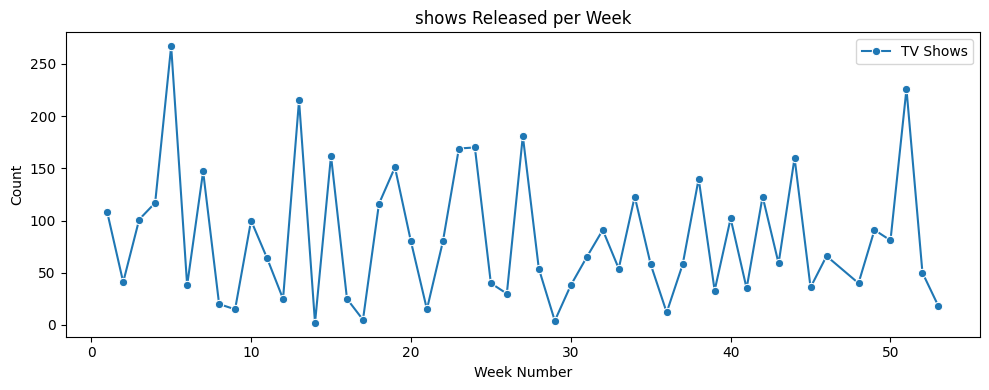

In [ ]:
# shows week counts
shows = df[df['type'] == 'TV Show']
shows_by_week = shows.groupby('week')['show_id'].count().reset_index(name='shows_count')
plt.figure(figsize=(10, 4))
sns.lineplot(data=shows_by_week, x='week', y='shows_count', marker='o', label='TV Shows')
plt.title('shows Released per Week')
plt.xlabel('Week Number')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

conclusion: It is best to release movies in the early weeks , that is the peek time , when compared to rest of the weeks.
TV Shows should be released between 5th week to 10th week or in the ending, from 50th to 52th week .

Analysing which month is the best to release movies / TV Shows.

In [ ]:
# converting date_added to month type
df['month'] = df['date_added'].dt.month_name()
df['month_num'] = df['date_added'].dt.month

/tmp/ipython-input-1990995685.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=movies_by_month, x='month', y='movie_count', palette='Blues_d')


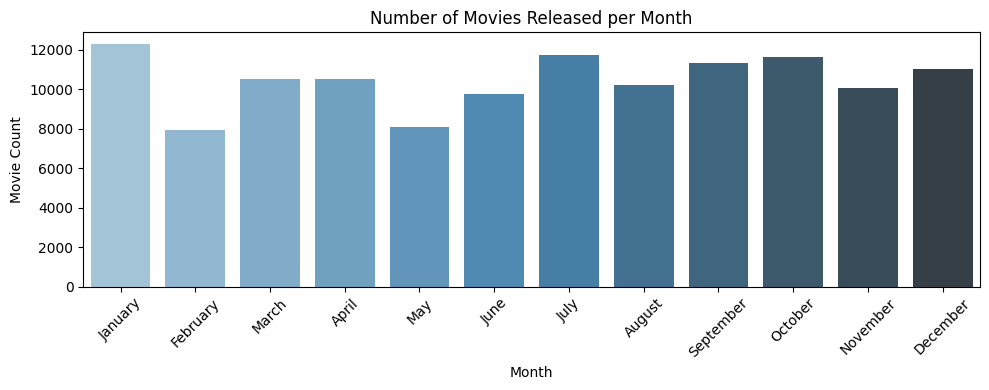

In [ ]:
movies = df[df['type'] == 'Movie']
movies_by_month = movies.groupby(['month', 'month_num'])['show_id'].count().reset_index(name='movie_count')
movies_by_month = movies_by_month.sort_values('month_num')
plt.figure(figsize=(10, 4))
sns.barplot(data=movies_by_month, x='month', y='movie_count', palette='Blues_d')
plt.title('Number of Movies Released per Month')
plt.xlabel('Month')
plt.ylabel('Movie Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipython-input-1600664967.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tv_by_month, x='month', y='tv_count', palette='Purples_d')


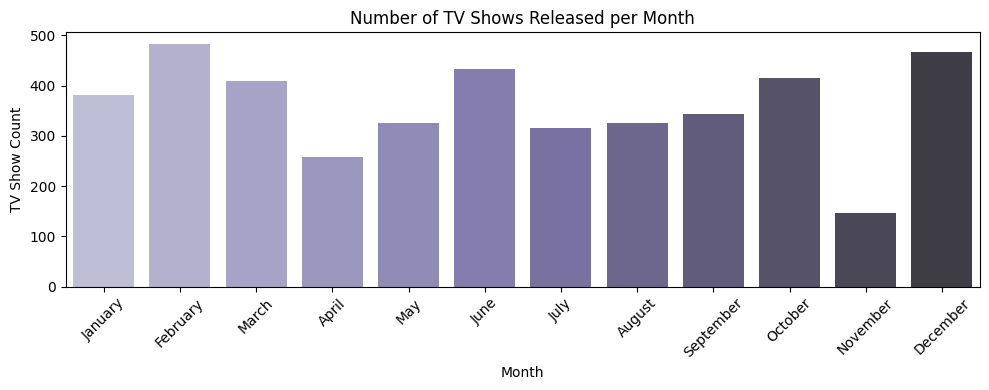

In [ ]:
tv_shows = df[df['type'] == 'TV Show']
tv_by_month = tv_shows.groupby(['month', 'month_num'])['show_id'].count().reset_index(name='tv_count')
tv_by_month = tv_by_month.sort_values('month_num')
plt.figure(figsize=(10, 4))
sns.barplot(data=tv_by_month, x='month', y='tv_count', palette='Purples_d')
plt.title('Number of TV Shows Released per Month')
plt.xlabel('Month')
plt.ylabel('TV Show Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

For movies , the best months to release is January cause it is the start of year ,Netflix will add new content .July as it is summer vacations , families, students, and young viewers have more free time, boosting engagement.  
For TV Shows ,Febuary and December are best time to release as After a heavy January movie push, Netflix may release TV shows in Feb to spread engagement across weeks. December is part of the global holiday season — Christmas, New Year, and school vacations. People have more leisure time, making it ideal for binge-watching.

Now lets see which actors are more popular or have appeared in most shows/movies in Netflix.

In [ ]:
df_actors = df[df['cast'] != 'Unknown cast']
top_actors = (
    df_actors.groupby('cast')['title']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='title_count')
)

In [ ]:
print(top_actors)

                cast  title_count
0        Anupam Kher           42
1     Shah Rukh Khan           34
2   Naseeruddin Shah           31
3       Akshay Kumar           30
4            Om Puri           30
5   Amitabh Bachchan           28
6       Paresh Rawal           28
7        Boman Irani           27
8     Kareena Kapoor           25
9  Samuel L. Jackson           21


similarly , the most popular directors in Netflix can be found out.

In [ ]:
df_director = df[df['director'] != 'Unknown director']
top_directors = (
    df_director.groupby('director')['title']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='title_count')
)

/tmp/ipython-input-3169078955.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_director.groupby('director')['title']


In [ ]:
print(top_directors)

                 director  title_count
0  Raúl Campos, Jan Suter           18
1            Marcus Raboy           15
2               Jay Karas           14
3     Cathy Garcia-Molina           13
4             Jay Chapman           12
5         Youssef Chahine           12
6         Martin Scorsese           12
7        Steven Spielberg           11
8        Don Michael Paul           10
9            David Dhawan            9


This analysis is crucial as it gives us the insights about which cast is popular or most watched , so Netflix can cast them again in movies/ TV shows.

People also prefer watching certain directors movies/shows , and this analysis can state which directors are most popular among audience.


Genre gives us the field, which most viewers prefer to watch.
As movies are most likeable to binge than TV Shows . we perfor an analysis on Movies , their prefered Genre.  

In [ ]:
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['genre'] = movies_df['listed_in'].str.split(',')
movies_df = movies_df.explode('genre')
movies_df['genre'] = movies_df['genre'].str.strip()
movies_df = movies_df[movies_df['genre'].str.contains('Movies', case=False, na=False)]
top_genres = movies_df['genre'].value_counts().nlargest(10).index
top_movies_df = movies_df[movies_df['genre'].isin(top_genres)]


plt.figure(figsize=(12, 6))
sns.countplot(data=top_movies_df, x='genre', order=top_genres, palette='viridis')

plt.title('Top 10 Movie Genres (Containing "Movies")')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Conclusion: International movies are most likely watched among rest of all.

Let us calculate after how many days it is best to add a movie, after release year . This data tells us the ,what is the best time to add  movies

In [ ]:
#  date added
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['release_date'] = pd.to_datetime(movies_df['release_year'].astype(str), errors='coerce', format='%Y')
movies_df = movies_df.dropna(subset=['date_added', 'release_date'])
movies_df['days_to_add'] = (movies_df['date_added'] - movies_df['release_date']).dt.days
movies_df = movies_df[movies_df['days_to_add'] >= 0]


most_common_gap = movies_df['days_to_add'].mode().iloc[0]
print(f"Most movies are added to Netflix after approximately {most_common_gap} days from their release.")

# Insights





Movies dominate the content library, but TV Shows have increased steadily
in recent years.

Indicates Netflix is diversifying its content to encourage long-term engagement through binge-worthy series.

The United States contributes the highest number of both movies and TV shows, followed by India, UK, and Canada.

This shows a strong focus on English-language content, though international presence is growing.

Most frequent genres include Dramas, International Movies, and Comedies.

Movies are most commonly added in January and July, aligning with New Year and summer breaks.

TV Shows are commonly added in February and December, likely to align with holiday seasons.

On average, there is a gap of around 1 year between the original movie release and its addition to Netflix.

#Recommendations

Invest more in non-US markets like India, Japan, Korea, and Brazil where there is strong demand for local-language content.

Leverage country-wise popularity insights to license or produce localized originals.

International Dramas and Comedies are highly consumed — Netflix should focus on expanding these genres in different languages and regions.

Introduce more genre-specific campaigns.

Continue adding movies in Jan/Jul and TV shows in Feb/Dec based on current engagement trends.

Explore monthly content scheduling for smaller markets based on national holidays or events.

Theres a need to shorten the time between release year and adding content.


